In [39]:
# import gensim.downloader as api

# # Download pretrained model.wv
# # Trained by Google on a large corpus of news articles
# # About 3 million words and phrases
# # Trained on roughly 100 billion words from Google News
# # Vector size = 300 dimensions
# # Around 1.5 GB in memory

# model = api.load("word2vec-google-news-300")

In [58]:
import tensorflow as tf 
import re
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np



In [59]:
model = Sequential()
model.add(Dense(4, activation = 'relu', input_shape=(2,)))
model.add(Dense(3, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

In [60]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

In [61]:
model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                │ (None, 4)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │            15 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31 (124.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

In [62]:
texts = [
    "I love this product.",
    "This movie is amazing.",
    "The food was delicious.",
    "I am very happy today.",
    "The service was excellent.",
    "I hate this product.",
    "This movie is boring.",
    "The food was terrible.",
    "I am very sad today.",
    "The service was bad."
]

labels = np.array([1,1,1,1,1,0,0,0,0,0])

In [63]:
tfidf = TfidfVectorizer()
X = tfidf.fit_transform(texts)

text_vec = X.toarray()
print(text_vec)
print(tfidf.get_feature_names_out())

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.6804329  0.
  0.57843013 0.         0.         0.         0.         0.44992184
  0.         0.         0.        ]
 [0.         0.58899657 0.         0.         0.         0.
  0.         0.         0.         0.5007009  0.         0.5007009
  0.         0.         0.         0.         0.         0.3894615
  0.         0.         0.        ]
 [0.         0.         0.         0.         0.62051954 0.
  0.5274983  0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.4103054  0.
  0.         0.         0.4103054 ]
 [0.47761213 0.         0.         0.         0.         0.
  0.         0.56183624 0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.47761213 0.47761213 0.        ]
 [0.         0.         0.         0.         0.         0.62051954
  0.         0.         0.         0.         

In [64]:
model = Sequential()
model.add(Dense(8,activation = 'relu', input_shape = (text_vec.shape[1],)))
model.add(Dense(1,activation = 'sigmoid'))

model.compile(
    optimizer ='adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

model.summary()

Model: "sequential_16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_35 (Dense)                │ (None, 8)              │           176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 185 (740.00 B)

 Trainable params: 185 (740.00 B)

 Non-trainable params: 0 (0.00 B)

In [65]:
history = model.fit(text_vec, labels, epochs = 100, verbose =0)



In [66]:
new_texts = [
    "I want to work in AI and machine learning"]
new_vectors = tfidf.transform(new_texts).toarray()
predictions = model.predict(new_vectors)
print("Predicted probabilities for new texts:")
print(predictions)
 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Predicted probabilities for new texts:
[[0.5087135]]


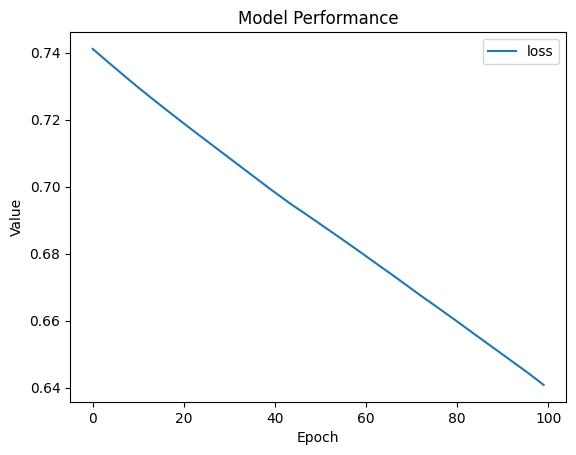

In [67]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'], label='loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model Performance')
plt.legend()
plt.show()

class assignment


In [70]:
tokens = []
for i in texts:
    i = i.lower()
    i = re.sub(r"[^a-zA-Z\s]", "", i)
    words = i.split()
    tokens.append(words)

print(tokens)

[['i', 'love', 'this', 'product'], ['this', 'movie', 'is', 'amazing'], ['the', 'food', 'was', 'delicious'], ['i', 'am', 'very', 'happy', 'today'], ['the', 'service', 'was', 'excellent'], ['i', 'hate', 'this', 'product'], ['this', 'movie', 'is', 'boring'], ['the', 'food', 'was', 'terrible'], ['i', 'am', 'very', 'sad', 'today'], ['the', 'service', 'was', 'bad']]


In [ ]:
word_model = Word2Vec(
    sentences=tokens,
    vector_size=50,
    window=2,
    min_count=1,
    workers=1,
    sg=1
)


Word2Vec<vocab=22, vector_size=50, alpha=0.025>


In [ ]:
sentence_vectors = []

for sentence in tokens:
    word_vectors = []

    for word in sentence:
        word_vectors.append(word_model.wv[word])

    sentence_vector = np.mean(word_vectors, axis=0)
    sentence_vectors.append(sentence_vector)

new_word = np.array(sentence_vectors)

print(new_word.shape)

(10, 50)


In [78]:
model2 = Sequential()
model2.add(Dense(8,activation = 'relu', input_shape = (X_word.shape[1],)))
model2.add(Dense(1,activation = 'sigmoid'))

c:\Users\yuvra\Desktop\UNI\NLP\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [80]:
model2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "sequential_21"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_37 (Dense)                │ (None, 8)              │           408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 417 (1.63 KB)

 Trainable params: 417 (1.63 KB)

 Non-trainable params: 0 (0.00 B)

In [82]:
history = model2.fit(X_word,labels,epochs=100,verbose=0)
loss, accuracy = model2.evaluate(X_word, labels)

print("Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 1.0000 - loss: 0.6862
Accuracy: 1.0


In [83]:
new_tokens = []
for i in new_texts:
    i = i.lower()
    i = re.sub(r"[^a-zA-Z\s]", "", i)
    words = i.split()
    new_tokens.append(words)

print(new_tokens)

new_texts = [
    "I want to work in AI and machine learning"]



[['i', 'want', 'to', 'work', 'in', 'ai', 'and', 'machine', 'learning']]


In [86]:
word_model.build_vocab(new_tokens, update=True)

word_model.train(
    new_tokens,
    total_examples=len(new_tokens),
    epochs=100
)

new_sentence_vectors = []

for sentence in new_tokens:
    word_vectors = []

    for word in sentence:
        word_vectors.append(word_model.wv[word])

    new_sentence_vector = np.mean(word_vectors, axis=0)
    new_sentence_vectors.append(new_sentence_vector)

new_word = np.array(new_sentence_vectors)

print(new_word.shape)

(1, 50)


In [87]:
predictions = model2.predict(new_word)
print("Predicted probabilities for new texts:")
print(predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
Predicted probabilities for new texts:
[[0.5034771]]


In [89]:
import matplotlib.pyplot as plt
plt.plot(predictions.prediction['loss'], label='loss')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Model Performance')
plt.legend()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'prediction'